# DSA 8501 Text & Unstructured Data Analytics - CAT 1
Farzeen Wilson (169169)

#The Language of Law vs. The Common Mwananchi: Assessing the Accessibility of Kenya’s Constitution

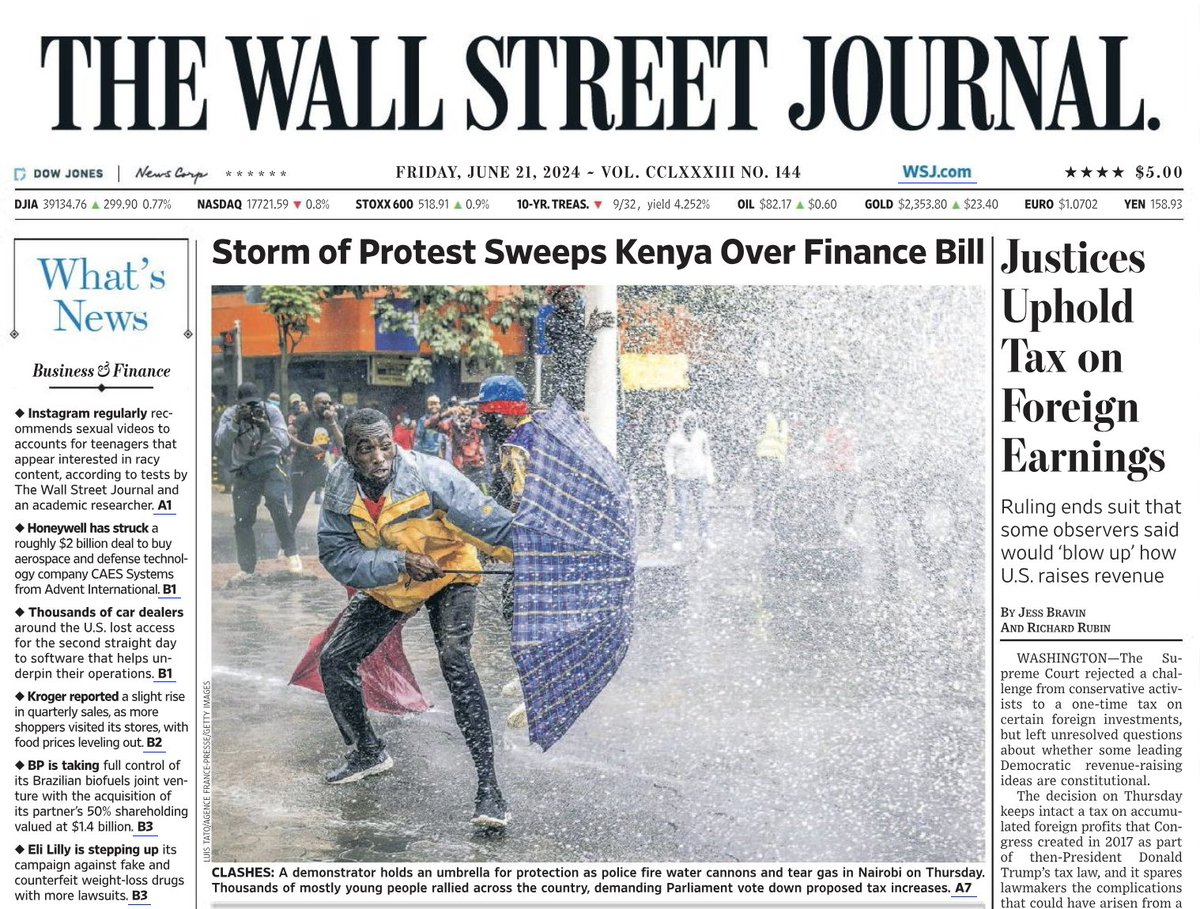

## Background

The 2024 Finance Bill protests in Kenya revealed a big disconnect in civil engagement. While there was large public interest about the governing of the country, civic education amongst citizens was low. THere was a wave of social media accounts gaining momentum focused on explaining the different arms of the government and teaching citizens in simpler terms and even having the content done in native languages. Many young professionals including myself, are facing significant taxation ana deductions to our salaries, which is currently around 40% for many. Many citizens lack the tools to interpret the legal frameworks governing these deductions. The Constitution of Kenya (2010) is the supreme law, but the protests shows that citizens who did not grow up in politically active households, the Constitution remains intimidating and hard to understand. This project focuses on the "readability" of the Constitution, specifically questioning if the language used effectively excludes the very citizens it is meant to protect.

##Problem Statement

For any democracy to function like ours, laws must be understood by the average citizen, particularly the "working class" demographic that bears the tax burden in this country. However, there is a disconnect in our country around the Constitution. The specific problem this study addresses is the language barrier with the way the law itself is written for the citizens to understand. Currently, we don't know if certain chapters are harder to read than others. Without analyzing the text itself, we can't confirm if critical sections, especially around how public funds are colelcted and disbursed, are written at a level that excludes the average working Kenyan.


##Justification

This study is justified by the current socio-political climate in the country and rising interest in the management (or mis-management) of public funds, as seen from the Finance Bill protests in 2024. Many Kenyans find the laws governing these taxes confusing or intimidating. If the Public Finance chapter requires a post-graduate reading level to understand, it effectively pushes away the majority of voters and taxpayers from holding the government accountable. By examining this "accessibility gap" using Data Science, we can provide empirical evidence on why civic education is failing, dispelling the narrative that  citizens don't care, but prving that the source text may be structurally too difficult for a layperson.

##Assumptions

We assume that readability formulas (like the Flesch-Kincaid Grade Level and Gunning Fog Index) are valid proxies for accessibility in the Kenyan context, despite being developed for American English.

We assume that sentence length and syllable count are accurate indicators of difficulty. This means that longer words and sentences would equal a higher level of literacy to undestand.

We assume the text version of the Constitution downloaded from Kenya Law Reporting is the accurate, official version without errors.

##Scope

The analysis is strictly limited to the English version of the Constitution of Kenya (2010).

We will exclude specific Acts of Parliament (such as the Finance Bill 2024) from the ranking. This is because Bills are often drafted as sets of amendments (shorter texts) rather than longer-forms text, which would skew the readability metrics and create an untrue comparison with the full sentences of the Constitution.

The analysis will cover the entirety of the Constitution, segmented into its 18 distinct Chapters.

We will not limit the study to specific sections; instead, we will generate a comparative ranking of all chapters to identify where 'Public Finance' falls on the spectrum of difficulty relative to other chapters like 'The Bill of Rights' or 'Citizenship'. We will not analyze the Swahili version or subsequent Acts of Parliament.

##Hypothesis (NLP Related)

Based on the nature of the content, we propose the following hypotheses:


* Ranking Complexity: We hypothesize that Chapter 12  (Public Finance) will rank in the top quartile (top 25%) of difficulty across all 18 chapters. We predict its readability score (Flesch-Kincaid) will indicate a "University Grade Level," making it statistically harder to read than the "Bill of Rights" (Chapter 4), which we expect to be in the "easiest" quartile.

* Structure: We predict that Chapter 12 will have a Longer Average Sentence Length (ASL). Laws around public funds often contain complex conditional clauses (e.g., "subject to," "provided that"), which increase difficulty of comprehension compared to the statements found in the Bill of Rights.

* Vocabulary: We hypothesize that Chapter 12 will have a higher percentage of unique, non-common words. It is likely dominated by abstract technical nouns such "Equalisation," "Appropriation," "Consolidated", which create a an issue of understanding "jargon" for the average citizen.

##Data Description (NLP Related)

Data Source: The primary dataset is the full English text of the Constitution of Kenya (2010), obtained from the official Kenya Law Reporting database (kenyalaw.org).

Data Structure: The text consists of approximately 45,000 words. For analysis, it will be segmented into 18 distinct documents, where each document corresponds to a single Chapter (e.g., Doc_1 = "Sovereignty", Doc_12 = "Public Finance").


### Preprocessing:

* Segmentation: We will use Python to split the text files by the keyword "CHAPTER".

* Cleaning: We will use Regular Expressions (Regex) to remove non-narrative "noise" such as Article numbers (e.g., "201. (1)"), marginal notes, and page footers to ensure that the readability formulas are analyzing the sentences, not the formatting.

* Tokenization: The text will be broken down into individual tokens (words) to calculate sentence length and syllable counts.

##Exploratory Data Analytics

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pypdf
from pypdf import PdfReader

In [2]:
#Data Cleaning Steps
def extract_and_clean_pdf(pdf_path):
    print(f"Loading {pdf_path}...")
    reader = PdfReader(pdf_path)
    full_text = ""

    #extracting text from all pages
    for page in reader.pages:
        full_text += page.extract_text() + "\n"

    # removing headers, footers and page numbers
    full_text = re.sub(r'Constitution of Kenya, 2010', '', full_text)
    full_text = re.sub(r'\n\s*\d+\s*\n', '\n', full_text)

    #splitting text into chapters using regex
    split_pattern = r'(CHAPTER\s+[A-Z]+(?:-[A-Z\s]+)?)'
    parts = re.split(split_pattern, full_text)

    chapter_dict = {}
    current_chapter = "Preamble"

    for part in parts:
        part = part.strip()
        if part.startswith("CHAPTER"):
            current_chapter = part.split('-')[0].replace('\n', ' ').title()
        elif len(part) > 100:
            # removing article numbers
            clean_content = re.sub(r'\d+\.\s*\(\d+\)', '', part)
            clean_content = re.sub(r'\(\w\)', '', clean_content)
            clean_content = ' '.join(clean_content.split())

            #appending to current chapter for article numbers
            if current_chapter in chapter_dict:
                chapter_dict[current_chapter] += " " + clean_content
            else:
                chapter_dict[current_chapter] = clean_content

    return chapter_dict

In [3]:
#incorporating the readility measures
def count_syllables(word):
    word = word.lower()
    count = 0
    vowels = "aeiouy"
    if len(word) == 0: return 0
    if word[0] in vowels: count += 1
    for i in range(1, len(word)):
        if word[i] in vowels and word[i - 1] not in vowels:
            count += 1
    if word.endswith("e"): count -= 1
    if count == 0: count += 1
    return count

def get_flesch_kincaid_score(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if len(s.split()) > 3]
    words = re.findall(r'\w+', text)

    n_sents = len(sentences)
    n_words = len(words)

    if n_sents == 0 or n_words == 0: return 0

    n_syllables = sum(count_syllables(w) for w in words)

    #getting average sentence length and syllabes per word
    asl = n_words / n_sents
    asw = n_syllables / n_words

    fk_grade = (0.39 * asl) + (11.8 * asw) - 15.59
    return round(fk_grade, 2)

In [4]:
path = "/content/The_Constitution_of_Kenya_2010.pdf"
chapters = extract_and_clean_pdf(path)

#calculating scores
results = []
for title, content in chapters.items():
    score = get_flesch_kincaid_score(content)

    #filtering out empty or "Schedule" sections
    if "Schedule" not in title and score > 0:
        results.append({"Chapter": title, "Grade_Level": score})

df = pd.DataFrame(results).sort_values(by="Grade_Level", ascending=False)

Loading /content/The_Constitution_of_Kenya_2010.pdf...


/tmp/ipykernel_9467/1074006271.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Grade_Level', y='Chapter', data=df, palette=colors)


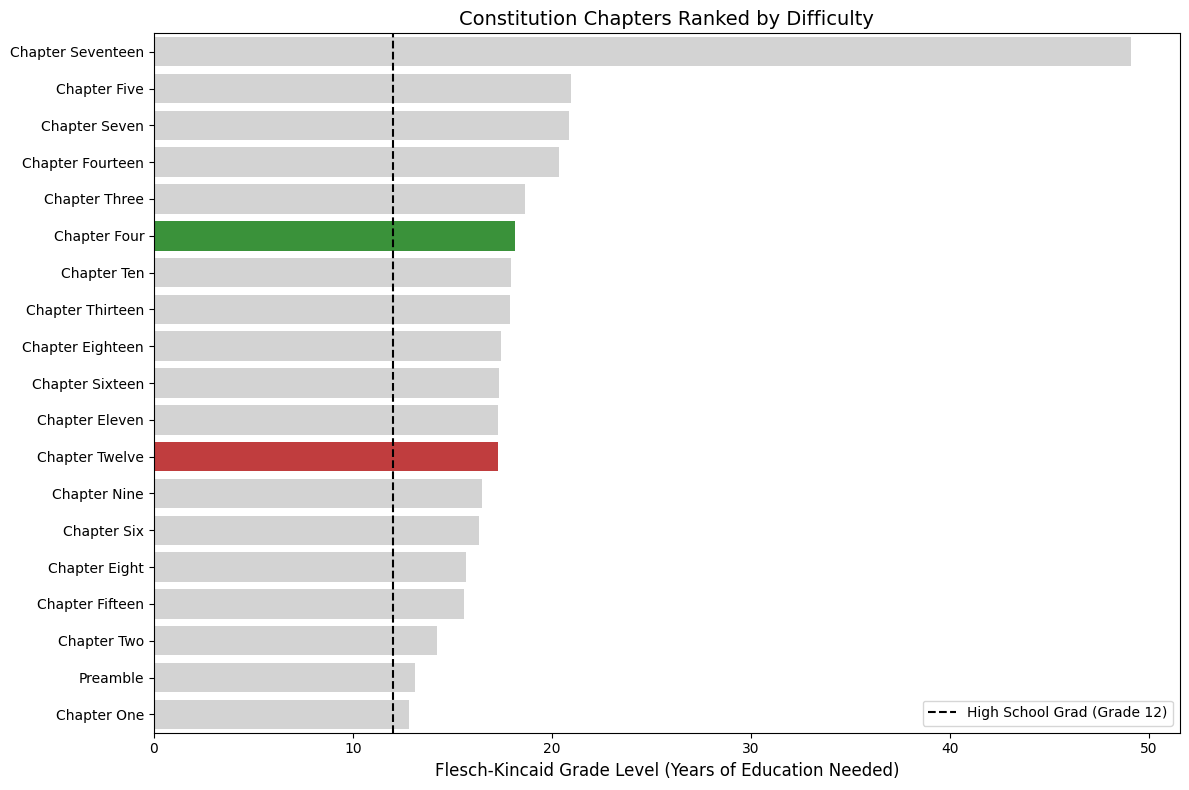

In [5]:
#Visualization 1-Hardest Chapters
plt.figure(figsize=(12, 8))

#defining colours to compare Bill of Rights and FInance Bill
colors = []
for c in df['Chapter']:
    text = c.upper()

    if 'TWELVE' in text or ' 12' in text:
        colors.append('#D62728')
    elif ('FOUR' in text and 'FOURTEEN' not in text) or (' 4' in text and '14' not in text):
        colors.append('#2CA02C')
    else:
        colors.append('#D3D3D3')

sns.barplot(x='Grade_Level', y='Chapter', data=df, palette=colors)

#adding reference line to show what high school graduates would be able to understand
plt.axvline(x=12, color='black', linestyle='--', label='High School Grad (Grade 12)')

plt.title('Constitution Chapters Ranked by Difficulty', fontsize=14)
plt.xlabel('Flesch-Kincaid Grade Level (Years of Education Needed)', fontsize=12)
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

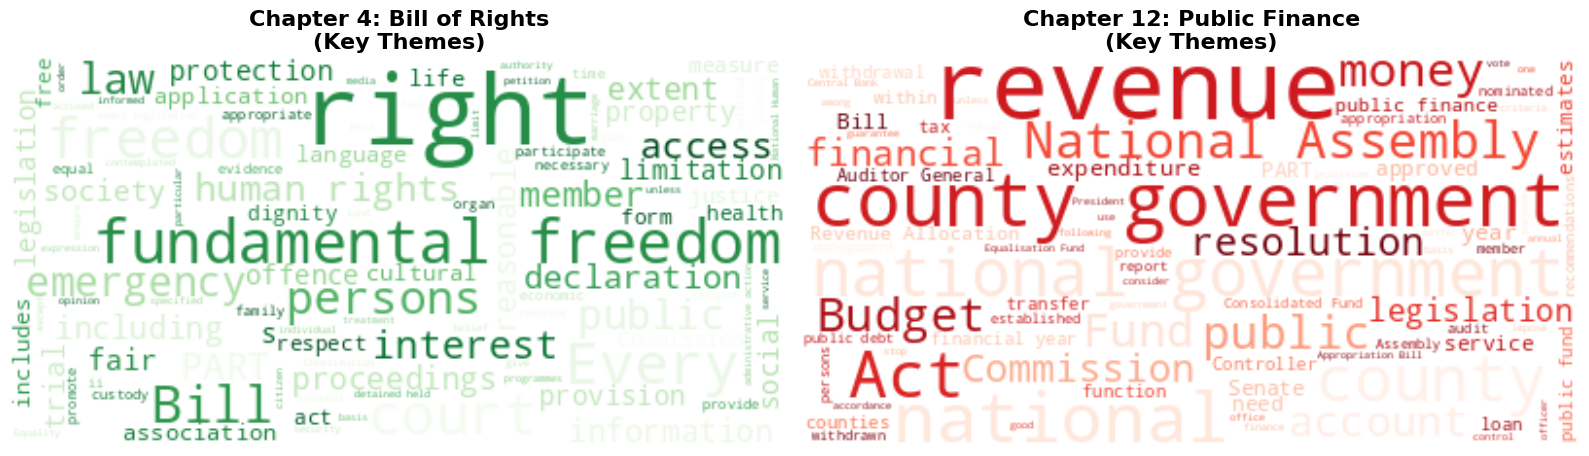

In [6]:
#Visualization 2-Wordclouds
from wordcloud import WordCloud, STOPWORDS
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["shall", "may", "person", "clause", "article", "section", "sub", "Kenya", "State", "Parliament"])

def plot_wordcloud(text, title, ax, color_map):
    wc = WordCloud(
        background_color='white',
        stopwords=custom_stopwords,
        max_words=100,
        max_font_size=50,
        random_state=42,
        colormap=color_map
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')

#comparing the 2 chapters
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
chapter_4_text = ""
chapter_12_text = ""

for title, content in chapters.items():
    if "FOUR" in title.upper() and "FOURTEEN" not in title.upper():
        chapter_4_text = content
    elif "TWELVE" in title.upper():
        chapter_12_text = content

plot_wordcloud(chapter_4_text, "Chapter 4: Bill of Rights\n(Key Themes)", axes[0], 'Greens')
plot_wordcloud(chapter_12_text, "Chapter 12: Public Finance\n(Key Themes)", axes[1], 'Reds')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9467/3685002625.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Diversity', y='Chapter', data=df_div, palette=colors_div)


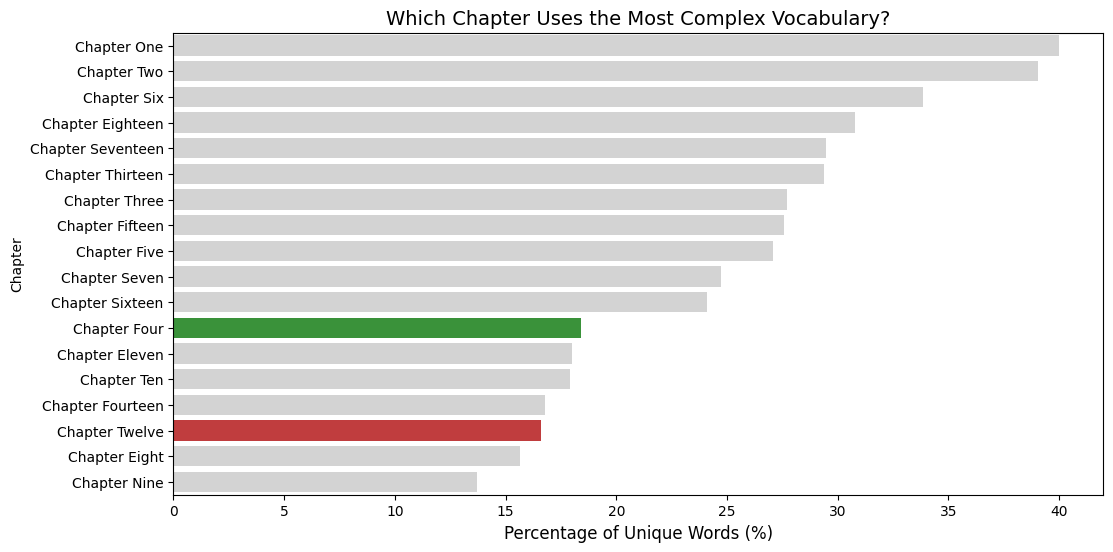

In [7]:
#Visualization 3- Richness of Vocabulary used
diversity_data = []

for title, content in chapters.items():
    words = re.findall(r'\w+', content.lower())
    if len(words) > 100:
        unique_words = set(words)
        diversity_score = (len(unique_words) / len(words)) * 100
        diversity_data.append({"Chapter": title, "Diversity": diversity_score})

df_div = pd.DataFrame(diversity_data).sort_values(by="Diversity", ascending=False)

plt.figure(figsize=(12, 6))

colors_div = []
for c in df_div['Chapter']:
    text = c.upper()
    if 'TWELVE' in text: colors_div.append('#D62728')
    elif ('FOUR' in text and 'FOURTEEN' not in text): colors_div.append('#2CA02C')
    else: colors_div.append('#D3D3D3')

sns.barplot(x='Diversity', y='Chapter', data=df_div, palette=colors_div)
plt.title('Which Chapter Uses the Most Complex Vocabulary?', fontsize=14)
plt.xlabel('Percentage of Unique Words (%)', fontsize=12)
plt.show()

## Machine Learning Solution to the Problem Identified

### Final Machine Learning Deployment
To translate the findings of this text analysis into an ML solution, a Deep Learning Natural Language Processing (NLP) dashboard was built and deployed to the cloud.

**The Mwananchi Legal Readability Scorer** allows citizens and policy drafters to test the accessibility of any legal text in real-time.

* **Live Dashboard:** [Click Here to Access the Deployed App](https://mwananchi-legal-scorer.streamlit.app)

* **Source Code:** [View the GitHub Repository Here](https://github.com/farzeenwilson/mwananchi-legal-scorer)

## Architecture and Model Selection

The development of the Mwananchi Legal Readability Scorer required balancing state-of-the-art Natural Language Processing with interpretability.

For the core classification engine, a Zero-Shot learning approach utilizing the facebook/bart-large-mnli model was selected.  This transformer-based model was chosen because it eliminates the need for a manually annotated training dataset of Kenyan legal texts, while still offering robust, out-of-the-box accuracy in distinguishing "accessible plain English" from "complex legal jargon" through deep semantic understanding.

To operationalize the model, Streamlit was selected as the deployment framework due to its seamless integration with Python-based machine learning pipelines and rapid cloud deployment capabilities. Furthermore, to prevent the solution from acting as a "black box," an Explainable AI (XAI) layer was engineered using Plotly and custom heuristic parsing.

By explicitly highlighting multisyllabic jargon directly within the text, the application moves beyond simply scoring readability to providing actionable, visual feedback for civic educators and policy drafters.

## Conclusion

This project started with a simple question: is the Kenyan Constitution actually written for the people it governs? After analyzing the text, the data gave a clear answer: not always. We found a massive "accessibility gap" across the document. While sections like the Bill of Rights (Chapter 4) use language that is relatively easy to grasp, the laws governing our taxes and public money (Chapter 12) are buried under heavy, complex jargon. When the rules about how the government collects and spends revenue require a university degree to understand, it naturally pushes the common Mwananchi out of the civic conversation.

Instead of just highlighting the problem, the second half of this project focused on building a practical solution. Using Natural Language Processing (NLP), I developed the Mwananchi Legal Readability Scorer, a live web application built with Streamlit. Under the hood, the app uses a pre-trained deep learning model (facebook/bart-large-mnli) to instantly evaluate any piece of legal text. When a user pastes a clause from a new Finance Bill, the app not only scores its complexity but actively highlights the specific jargon making it hard to read. Ultimately, this project proves that Data Science isn't just about crunching numbers; it can be used to build real-world tools that demand transparency and make the law accessible to everyone.